# Fate of the Solar Eclipse
## Evolution of the Moon–Sun Angular Size Ratio
**Clover Lee — Spring 2026**

---

This notebook models how the apparent angular sizes of the Moon and Sun change over time due to lunar recession, and estimates when total solar eclipses will no longer be possible.

### Outline
1. Imports & physical constants
2. Angular size model
3. NASA eclipse catalog — data loading & cleaning
4. Plot 1: Moon angular diameter vs. time
5. Plot 2: Moon/Sun angular size ratio $R(t)$ vs. time
6. Plot 3: Superimposed Sun & Moon disk comparison
7. Interactive widget: eclipse type by year

---
## 1. Imports & Physical Constants

In [21]:
import numpy as np                    # numerical arrays and math operations
import pandas as pd                   # tabular data — used to load and filter the NASA eclipse catalog
import matplotlib.pyplot as plt       # plotting library for all figures
import matplotlib.patches as patches  # drawing geometric shapes (circles for the disk comparison plot)
import ipywidgets as widgets          # interactive UI elements (slider for the widget)
from IPython.display import display   # needed to render widgets inline in Jupyter
from astropy import units as u        # unit-aware quantities — prevents silent unit conversion errors

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [22]:
# ── Physical constants ────────────────────────────────────────────────────────

D_moon   = 3_474.8       * u.km         # Moon's diameter
D_sun    = 1_392_700.0   * u.km         # Sun's diameter
d_moon_0 = 384_400.0     * u.km         # Moon's semi-major axis today (mean Earth-Moon distance)
d_sun    = 149_597_870.0 * u.km         # Mean Earth-Sun distance (1 AU)

e_moon   = 0.0549                                     # Moon's orbital eccentricity — how elliptical the orbit is
b_moon_0 = d_moon_0 * np.sqrt(1 - e_moon**2)          # semi-minor axis: b = a√(1-e²)

# The measured recession rate is 3.8 cm/yr; converting to km/yr for consistency with distances above
v_recession = (3.8 * u.cm / u.yr).to(u.km / u.yr)

# All time offsets in the model are measured relative to this year (t = 0)
YEAR_0 = 2026

print(f"Moon diameter:         {D_moon}")
print(f"Sun diameter:          {D_sun}")
print(f"Earth-Moon semi-major: {d_moon_0}")
print(f"Earth-Moon semi-minor: {b_moon_0:.1f}")
print(f"Earth-Sun distance:    {d_sun.to(u.au):.6f}")
print(f"Recession rate:        {v_recession:.2e}")

Moon diameter:         3474.8 km
Sun diameter:          1392700.0 km
Earth-Moon semi-major: 384400.0 km
Earth-Moon semi-minor: 383820.3 km
Earth-Sun distance:    1.000000 AU
Recession rate:        3.80e-05 km / yr


---
## 2. Angular Size Model

The small-angle approximation gives angular diameter:
$$\theta \approx \frac{D}{d}$$

The angular size ratio we care about is:
$$R(t) = \frac{\theta_\text{Moon}(t)}{\theta_\text{Sun}} = \frac{D_\text{Moon} / d_\text{Moon}(t)}{D_\text{Sun} / d_\text{Sun}}$$

Total solar eclipses are only possible when $R(t) \geq 1$.

In [23]:
# ── Time array ────────────────────────────────────────────────────────────────
# 10,000 evenly spaced points from 500 Myr in the past to 1.5 Gyr in the future
years = np.linspace(-500_000_000, 1_500_000_000, 10_000) * u.yr

def moon_distance(t_offset):
    """Earth-Moon semi-major axis at t_offset years from YEAR_0, assuming linear recession."""
    # Simple linear model: distance grows at a constant rate v_recession
    return d_moon_0 + v_recession * t_offset

def moon_perigee(t_offset):
    """Closest point in the Moon's orbit (perigee) at t_offset from YEAR_0.
    This is the relevant distance for eclipse possibility — the Moon appears largest here."""
    # At perigee, distance = semi-major axis × (1 - eccentricity)
    return moon_distance(t_offset) * (1 - e_moon)

def angular_size(diameter, distance):
    """Angular diameter in radians using the small-angle approximation: θ ≈ D/d."""
    # decompose() cancels the km/km units cleanly to a dimensionless ratio
    return (diameter / distance).decompose()

def ratio_R(t_offset):
    """Moon-to-Sun angular size ratio R at t_offset from YEAR_0.
    Total solar eclipses are only possible when R ≥ 1 (Moon appears at least as large as Sun).
    Uses perigee distance — eclipses only occur near perigee, not at mean distance."""
    theta_moon = angular_size(D_moon, moon_perigee(t_offset))  # Moon's angular size at perigee
    theta_sun  = angular_size(D_sun, d_sun)                    # Sun's angular size (constant)
    return theta_moon / theta_sun

# ── Compute arrays over the full time domain ──────────────────────────────────
d_moon_arr             = moon_distance(years)                        # mean semi-major axis at each time
theta_moon_arr         = angular_size(D_moon, d_moon_arr)           # Moon's mean angular size
theta_moon_perigee_arr = angular_size(D_moon, moon_perigee(years))  # Moon's angular size at perigee
R_arr                  = ratio_R(years)                              # Moon/Sun angular size ratio at perigee

# ── Crossover calculations: when does R = 1? ─────────────────────────────────
# Solve D_moon / (a*(1-e)) = D_sun / d_sun for the critical semi-major axis, then for t
t_crossover        = ((D_moon * d_sun / (D_sun * (1 - e_moon))) - d_moon_0) / v_recession  # last total eclipse (perigee)
t_crossover_apogee = ((D_moon * d_sun / (D_sun * (1 + e_moon))) - d_moon_0) / v_recession  # when apogee eclipses ended (lower bound)

year_crossover = YEAR_0 + t_crossover.to(u.yr).value  # convert time offset to a calendar year

print(f"Current R (today, perigee): {ratio_R(0 * u.yr):.4f}")
print(f"Linear crossover:           {t_crossover.to(u.Myr):.1f} from now")
print(f"Crossover range (apogee):   {t_crossover_apogee.to(u.Myr):.1f}")

Current R (today, perigee): 1.0274
Linear crossover:           277.1 Myr from now
Crossover range (apogee):   -804.7 Myr


---
## 3. NASA Eclipse Catalog — Data Loading & Cleaning

Data source: [NASA Five Millennium Canon of Solar Eclipses](https://eclipse.gsfc.nasa.gov/5MCSE/5MKSEcatalog.txt)

You can also download this file once and save it locally as `5MKSEcatalog.txt` in this folder to load faster. 

In [24]:
import os

LOCAL_PATH = "5MKSEcatalog.txt"                                    # local copy — avoids re-downloading on each run
NASA_URL   = "https://eclipse.gsfc.nasa.gov/5MCSE/5MKSEcatalog.txt"  # fallback if local file doesn't exist

# Use the local file if it has already been downloaded, otherwise fetch from NASA
source = LOCAL_PATH if os.path.exists(LOCAL_PATH) else NASA_URL
print(f"Loading from: {source}")

# Column names follow the catalog's fixed-width format specification:
# https://eclipse.gsfc.nasa.gov/5MCSE/5MCSEcat.html
col_names = [
    "Cat_Num", "Cat_Plate", "Year", "Month", "Day",
    "Greatest_Eclipse", "DT_s", "Luna_Num", "Saros_Num",
    "Ecl_Type", "QLE", "Gamma", "Ecl_Mag",
    "Lat", "Long", "Sun_Alt", "Sun_Azm",
    "Path_Width_km", "Central_Line_Dur"
]

# read_fwf parses fixed-width text where columns are aligned by character position
# skiprows=10 skips the file's header block; encoding="latin1" handles special characters in the older NASA file
df_raw = pd.read_fwf(
    source,
    skiprows=10,
    header=None,
    encoding="latin1"
)

# Assign column names — trim to however many columns were actually parsed
df_raw.columns = col_names[:len(df_raw.columns)]

df_raw.head()

Loading from: 5MKSEcatalog.txt


,Cat_Num,Cat_Plate,Year,Month,Day,Greatest_Eclipse,DT_s,Luna_Num,Saros_Num,Ecl_Type,QLE,Gamma,Ecl_Mag,Lat,Long,Sun_Alt,Sun_Azm,Path_Width_km,Central_Line_Dur
0,1,1,-1999,Jun,12,03:14:51,46438,-49456,5,T,-n,-0.2701,1.0733,6.0N,33.3W,74,344,247,06m37s
1,2,1,-1999,Dec,5,23:45:23,46426,-49450,10,A,n-,-0.2317,0.9382,32.9S,10.8E,76,21,236,06m44s
2,3,1,-1998,Jun,1,18:09:16,46415,-49444,15,T,p-,0.4994,1.0284,46.2N,83.4E,60,151,111,02m15s
3,4,1,-1998,Nov,25,05:57:03,46403,-49438,20,A,p-,-0.9045,0.9806,67.8S,143.8W,25,74,162,01m14s
4,5,1,-1997,Apr,22,13:19:56,46393,-49433,-13,P,-t,-1.4670,0.1611,60.6S,106.4W,0,281,NaN,NaN


In [25]:
df = df_raw.copy()  # work on a copy so the original parsed data stays intact

# Force numeric types — some entries may be non-numeric strings after fixed-width parsing
# errors="coerce" turns unparseable values into NaN instead of raising an error
df["Year"]    = pd.to_numeric(df["Year"],    errors="coerce")
df["Ecl_Mag"] = pd.to_numeric(df["Ecl_Mag"], errors="coerce")
df["Gamma"]   = pd.to_numeric(df["Gamma"],   errors="coerce")

# Drop rows missing the fields we rely on for analysis and plotting
df = df.dropna(subset=["Year", "Ecl_Type"])

# Eclipse type codes used in the catalog:
#   T = Total, A = Annular, H = Hybrid (total at some path points, annular at others), P = Partial
df["Ecl_Type"] = df["Ecl_Type"].str.strip()  # remove whitespace that can appear after fixed-width parsing

# Take just the first character so subtypes like "T+" or "A-n" all reduce to T, A, H, or P
df["Type_Simple"] = df["Ecl_Type"].str[0]

print(f"Total eclipses in catalog: {len(df):,}")
print("\nEclipse type counts:")
print(df["Type_Simple"].value_counts())

Total eclipses in catalog: 11,898

Eclipse type counts:
Type_Simple
P    4200
A    3956
T    3173
H     569
Name: count, dtype: int64


---
## 4. Plot 1: Moon Angular Diameter vs. Time

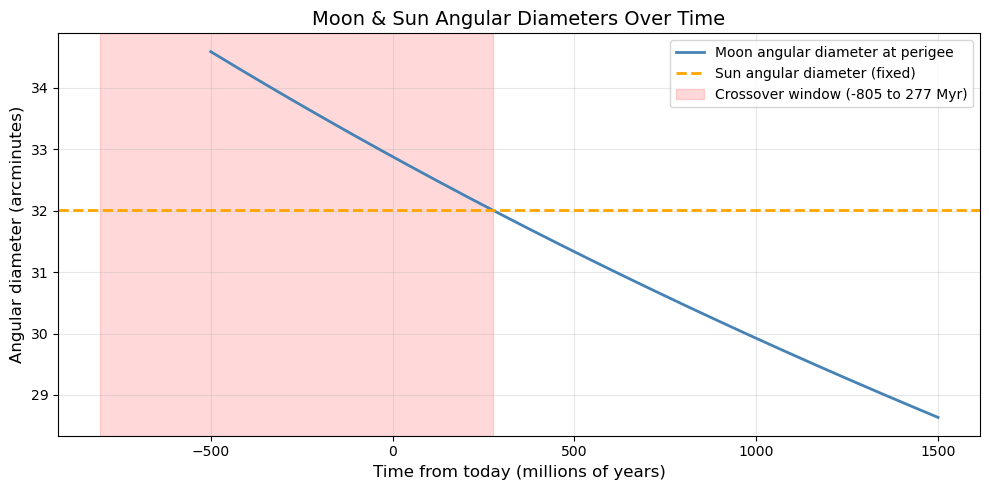

In [26]:
# Convert angular sizes from radians to arcminutes for a human-readable y-axis
# 1 radian = (180/π)° × 60 arcmin/°
RAD_TO_ARCMIN = (180 / np.pi) * 60

theta_moon_perigee_arcmin = theta_moon_perigee_arr.value * RAD_TO_ARCMIN     # Moon at perigee
theta_sun_arcmin          = angular_size(D_sun, d_sun).value * RAD_TO_ARCMIN  # Sun (constant)

# Convert years (astropy Quantity) to plain millions-of-years float for the x-axis
x_Myr = years.value / 1e6

fig, ax = plt.subplots(figsize=(10, 5))

# Primary curve: Moon's angular size at perigee — this is what determines eclipse possibility
# The curve starts above the Sun's line (total eclipses possible) and crosses it at +277 Myr
ax.plot(x_Myr, theta_moon_perigee_arcmin, color="steelblue", lw=2,
        label="Moon angular diameter at perigee")
# Sun's angular size treated as constant — Earth's orbital eccentricity (0.017) is too small to matter here
ax.axhline(theta_sun_arcmin, color="orange", lw=2, linestyle="--",
           label="Sun angular diameter (fixed)")

# Extract crossover times as plain floats for use in axvspan/axvline
t_ap = t_crossover_apogee.to(u.Myr).value  # apogee crossover — already in the past
t_pe = t_crossover.to(u.Myr).value         # perigee crossover — last possible total eclipse

# Shaded band marks the transition window:
# left edge = when Moon was too small even at apogee; right edge = when it's too small even at perigee
ax.axvspan(t_ap, t_pe, color="red", alpha=0.15,
           label=f"Crossover window ({t_ap:.0f} to {t_pe:.0f} Myr)")

ax.set_xlabel("Time from today (millions of years)", fontsize=12)
ax.set_ylabel("Angular diameter (arcminutes)", fontsize=12)
ax.set_title("Moon & Sun Angular Diameters Over Time", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot1_angular_diameter.png", dpi=150)
plt.show()

---
## 5. Plot 2: Moon/Sun Angular Size Ratio $R(t)$

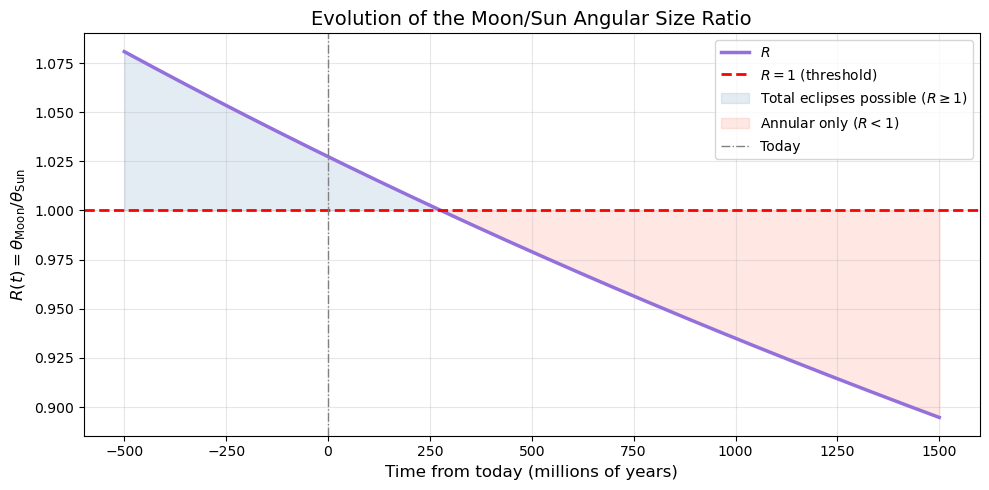

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

# R = Theta_Moon(perigee) / Theta_Sun — total eclipses possible when R ≥ 1
ax.plot(x_Myr, R_arr.value, color="mediumpurple", lw=2.5,
        label="$R$")

# R = 1 is the critical threshold separating total from annular eclipses
ax.axhline(1.0, color="red", lw=2, linestyle="--", label="$R = 1$ (threshold)")

# Blue shading: region where Moon at perigee is large enough to cover the Sun
ax.fill_between(x_Myr, R_arr.value, 1.0,
                where=(R_arr.value >= 1.0),
                alpha=0.15, color="steelblue",
                label="Total eclipses possible ($R \\geq 1$)")
# Red shading: region where even perigee is not close enough — annular eclipses only
ax.fill_between(x_Myr, R_arr.value, 1.0,
                where=(R_arr.value < 1.0),
                alpha=0.15, color="tomato",
                label="Annular only ($R < 1$)")

# Vertical marker so the viewer can locate today on the plot
ax.axvline(0, color="gray", lw=1, linestyle="-.", label="Today")

ax.set_xlabel("Time from today (millions of years)", fontsize=12)
ax.set_ylabel(r"$R(t) = \theta_\mathrm{Moon} / \theta_\mathrm{Sun}$", fontsize=12)
ax.set_title("Evolution of the Moon/Sun Angular Size Ratio", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot2_ratio.png", dpi=150)
plt.show()

---
## 6. Plot 3: Superimposed Sun & Moon Disk Comparison

This draws the Moon and Sun as circles at their correct *relative* angular sizes for a given year.

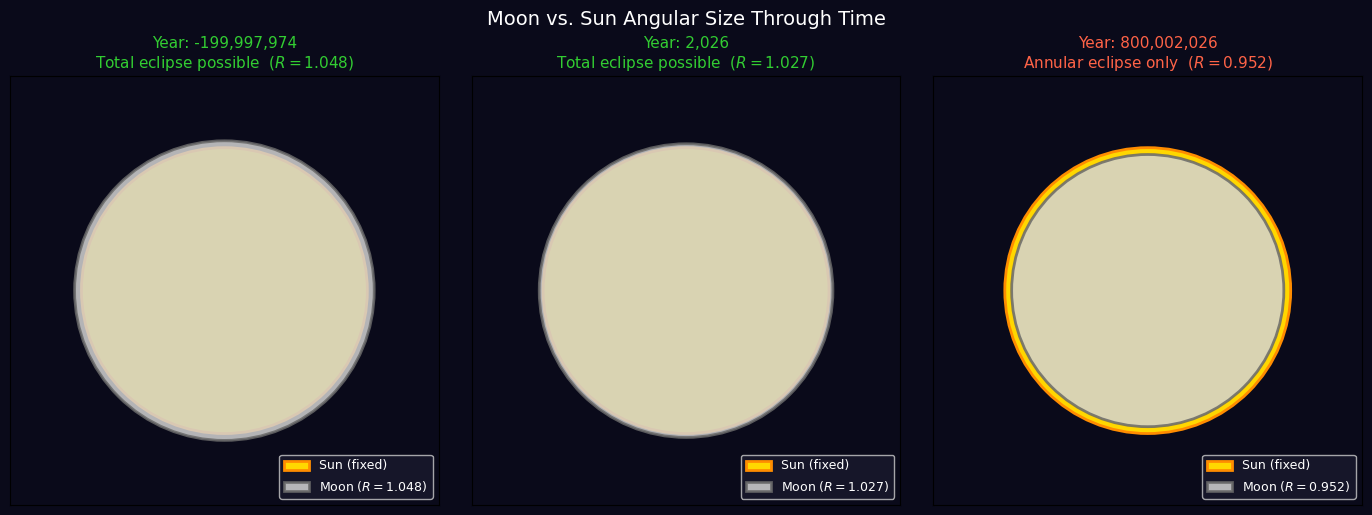

In [30]:
def draw_eclipse_disks(year, ax=None, title=None):
    """
    Draw superimposed Sun (orange) and Moon (gray) disks scaled to their
    relative angular sizes for the given year. Sun is fixed at radius=1.0;
    Moon's radius equals R(t), so when R > 1 it visibly overlaps and covers the Sun.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    # Convert the calendar year to a time offset, then compute R at that time
    t_offset = (year - YEAR_0) * u.yr
    R = ratio_R(t_offset).value  # extract plain float — patches.Circle needs a scalar, not a Quantity

    # Sun drawn at radius=1.0 as the fixed reference
    sun = patches.Circle((0, 0), radius=1.0,
                          color="gold", ec="darkorange", lw=2,
                          label=f"Sun (fixed)")
    # Moon's radius scales with R — when R > 1 the Moon covers the Sun (total eclipse possible)
    moon = patches.Circle((0, 0), radius=R,
                           color="lightgray", ec="dimgray", lw=2, alpha=0.85,
                           label=f"Moon ($R={R:.3f}$)")

    ax.add_patch(sun)
    ax.add_patch(moon)

    # Fixed axis bounds so all three panels share the same scale
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect("equal")       # equal aspect so circles don't appear as ellipses
    ax.set_facecolor("#0a0a1a")  # dark background to simulate the sky during an eclipse
    ax.set_xticks([])
    ax.set_yticks([])

    # Color the title green if total eclipses are possible, red if only annular
    eclipse_label = "Total eclipse possible" if R >= 1.0 else "Annular eclipse only"
    color_label   = "limegreen" if R >= 1.0 else "tomato"
    ax.set_title(title or f"Year: {year:,.0f}\n{eclipse_label}  ($R = {R:.3f}$)",
                 fontsize=11, color=color_label)
    ax.legend(loc="lower right", fontsize=9,
              facecolor="#1a1a2e", labelcolor="white")

    return R


# ── Three snapshot panels ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor("#0a0a1a")

example_years = [
    YEAR_0 - 200_000_000,   # 200 Myr ago — Moon was closer, R well above 1
    YEAR_0,                  # today — R just above 1, total eclipses still possible
    YEAR_0 + 800_000_000,   # 800 Myr in the future — Moon too small, annular only
]

# Draw one disk comparison per subplot
for ax, yr in zip(axes, example_years):
    draw_eclipse_disks(yr, ax=ax)

plt.suptitle("Moon vs. Sun Angular Size Through Time",
             fontsize=14, color="white", y=1.02)
plt.tight_layout()
plt.savefig("plot3_disks.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

---
## 7. Interactive Widget: Eclipse Type by Year

Drag the slider to any year and see whether a total eclipse would be possible.

In [31]:
from ipywidgets import interact, IntSlider

def interactive_disks(years_from_now=0):
    # Convert slider value (millions of years) to a calendar year
    year = YEAR_0 + years_from_now * 1_000_000
    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor("#0a0a1a")
    draw_eclipse_disks(year, ax=ax)  # reuse the same drawing function from Plot 3
    plt.tight_layout()
    plt.show()

# Slider ranges from 500 Myr in the past to 1.5 Gyr in the future, in 10 Myr steps
slider = IntSlider(
    value=0,     # start at today
    min=-500,    # 500 million years ago
    max=1500,    # 1.5 billion years in the future
    step=10,     # 10 million year increments
    description="Myr from now:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="600px")
)

# interact() links the slider to interactive_disks — dragging it reruns the function live
interact(interactive_disks, years_from_now=slider)

interactive(children=(IntSlider(value=0, description='Myr from now:', layout=Layout(width='600px'), max=1500, …

<function __main__.interactive_disks(years_from_now=0)>

Saved eclipse_animation.gif


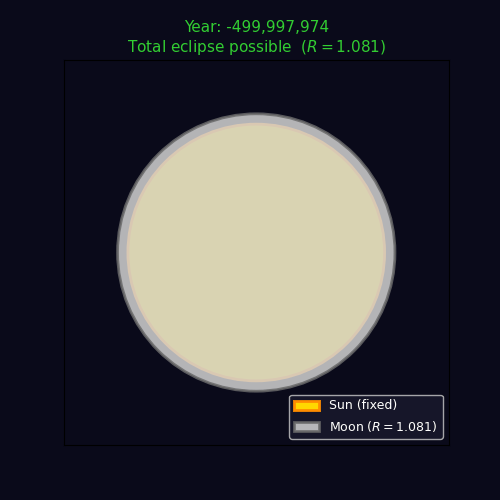

In [32]:
from matplotlib.animation import FuncAnimation
from IPython.display import Image

# Time steps: sweep forward from -500 Myr to +1500 Myr, then back — creates a ping-pong loop
anim_Myr = np.concatenate([
    np.linspace(-500, 1500, 120),  # forward sweep
    np.linspace(1500, -500, 120),  # reverse sweep
])

fig_anim, ax_anim = plt.subplots(figsize=(5, 5))
fig_anim.patch.set_facecolor("#0a0a1a")

def animate(i):
    ax_anim.clear()
    year = YEAR_0 + anim_Myr[i] * 1_000_000
    draw_eclipse_disks(year, ax=ax_anim)

# interval=50 ms per frame → full 240-frame cycle takes ~12 seconds
anim = FuncAnimation(fig_anim, animate, frames=len(anim_Myr), interval=50, repeat=True)
plt.close(fig_anim)

# PillowWriter renders each frame with Pillow and stitches them into an animated GIF
anim.save("eclipse_animation.gif", writer="pillow", fps=20)
print("Saved eclipse_animation.gif")

# Display the saved GIF inline
Image("eclipse_animation.gif")